In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# **Chuẩn bị và hiểu dữ liệu**

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Dataset/PimaDiabetes/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.shape

(768, 9)

In [5]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
cols_invalid_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

zero_counts = df[cols_invalid_zero].apply(lambda x: (x == 0).sum())

print("Số giá trị 0 (không hợp lý) trong các cột:")
print(zero_counts)


Số giá trị 0 (không hợp lý) trong các cột:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [8]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# **Phân tích dữ liệu**

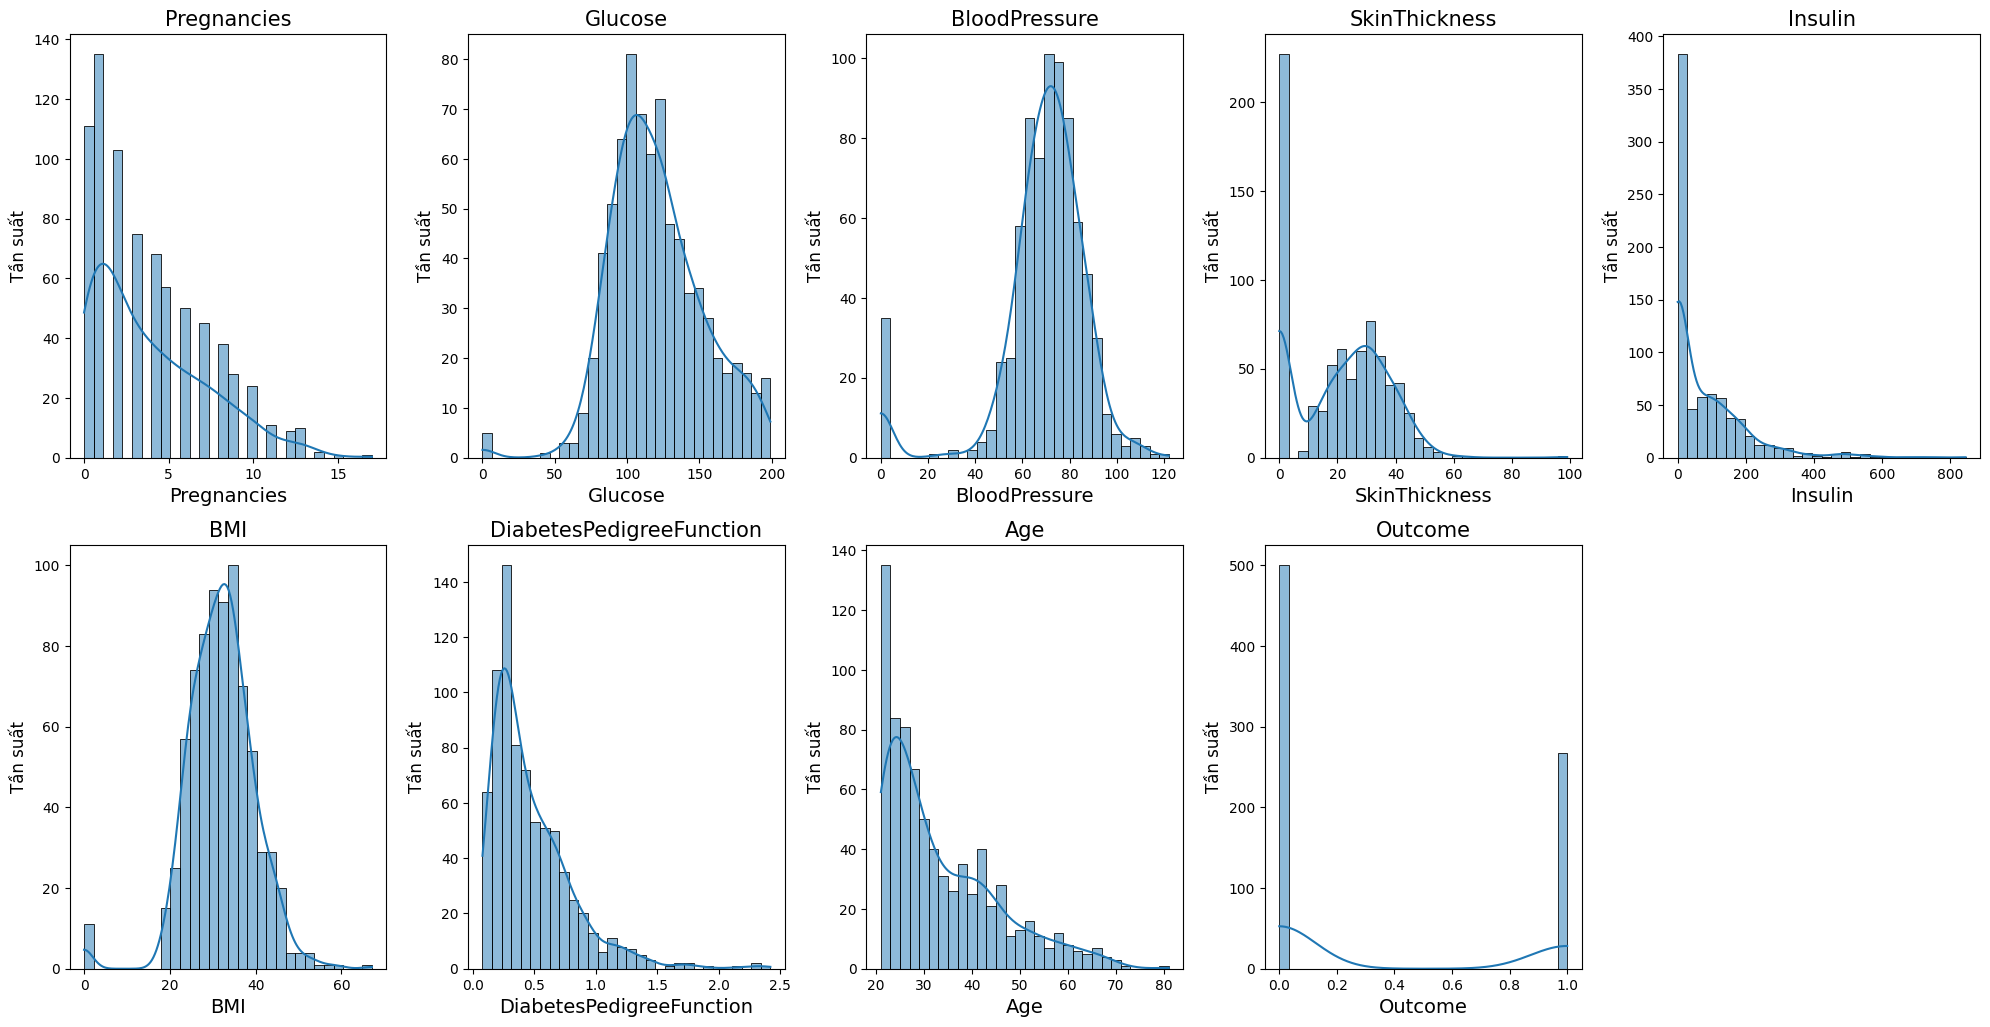

In [9]:
plt.figure(figsize=(20, 15))
plotnumber = 1

for column in df.columns:
    if plotnumber <= len(df.columns):  # Giới hạn để không lỗi
        ax = plt.subplot(3, 5, plotnumber)  # 3 hàng 5 cột, tổng 15 biểu đồ
        sns.histplot(df[column], kde=True, bins=30)
        plt.xlabel(column, fontsize=14)
        plt.ylabel('Tần suất', fontsize=12)
        plt.title(f'{column}', fontsize=15)
    plotnumber += 1

plt.tight_layout()
plt.show()

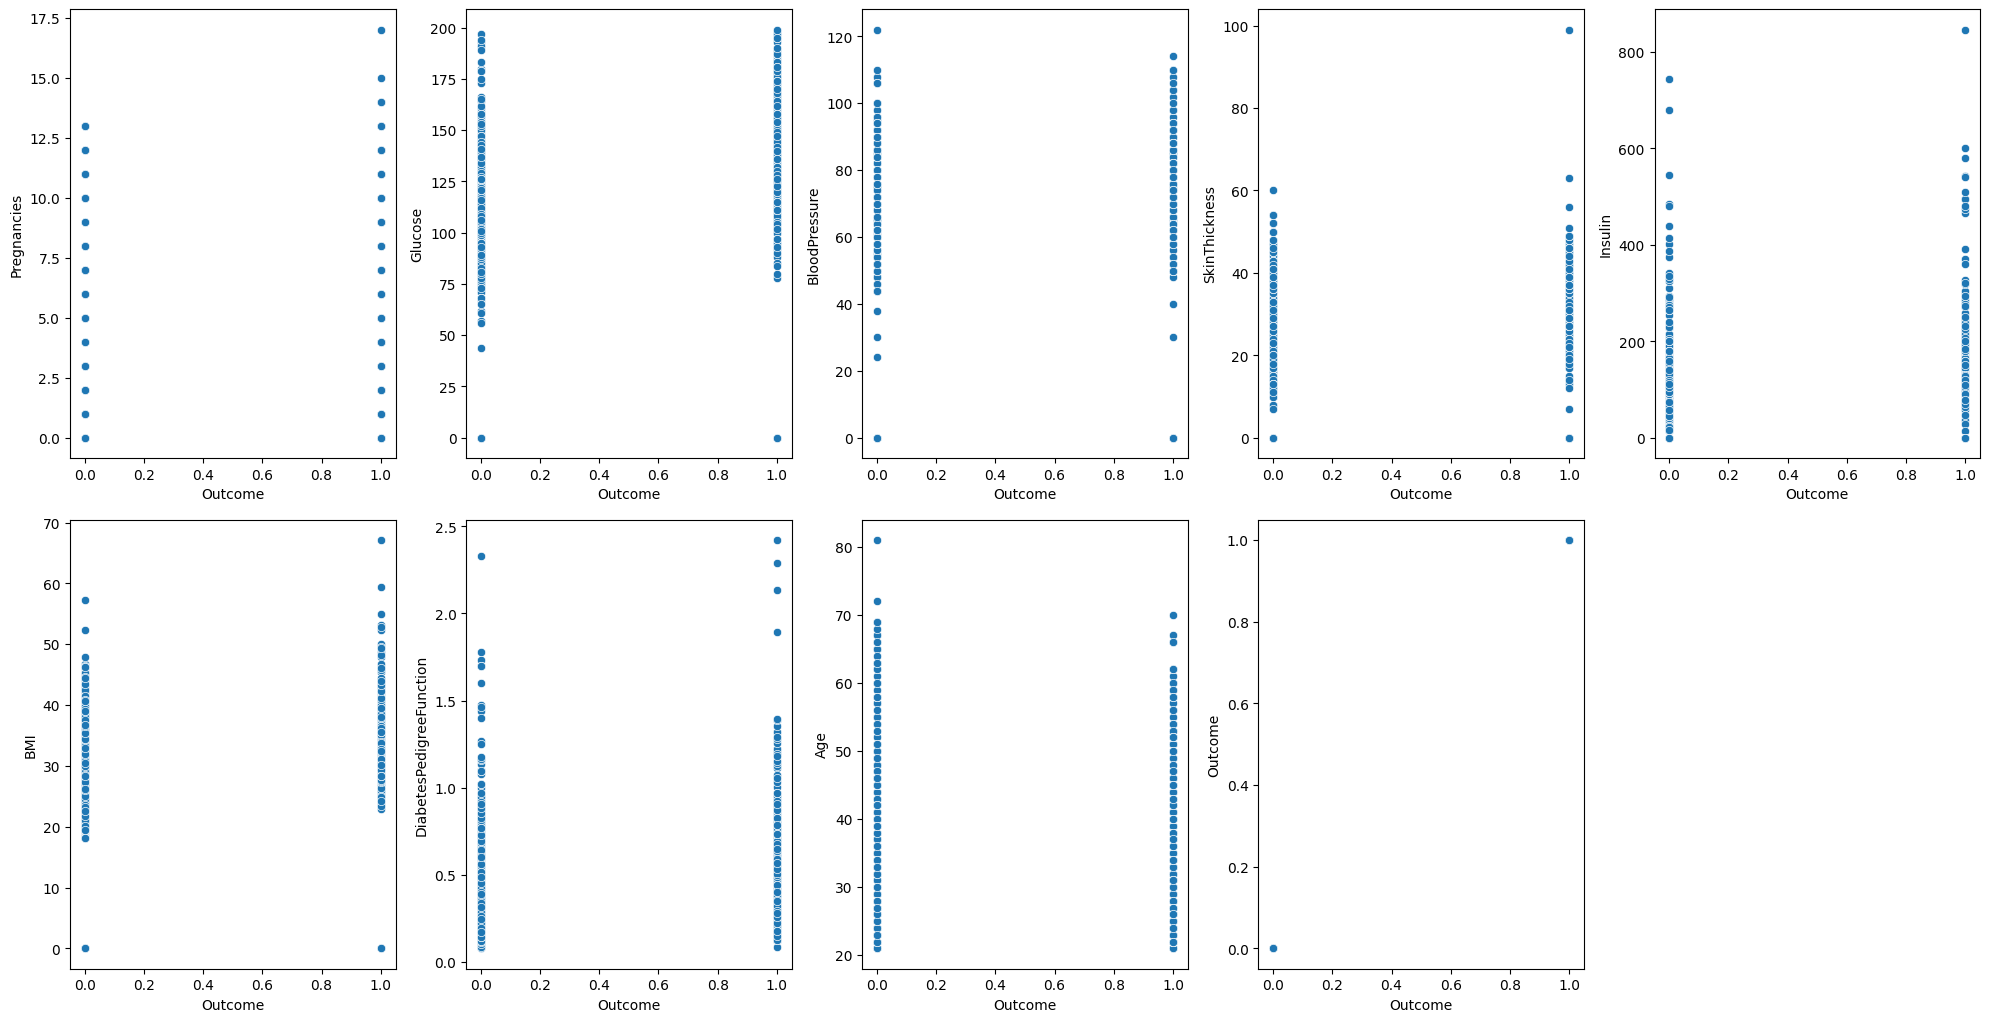

In [10]:
plt.figure(figsize = (20, 15))
plotnumber = 1

for column in df:
    if plotnumber <= 14:
        ax = plt.subplot(3, 5, plotnumber)
        sns.scatterplot(x = df['Outcome'], y = df[column])

    plotnumber += 1

plt.tight_layout()
plt.show()

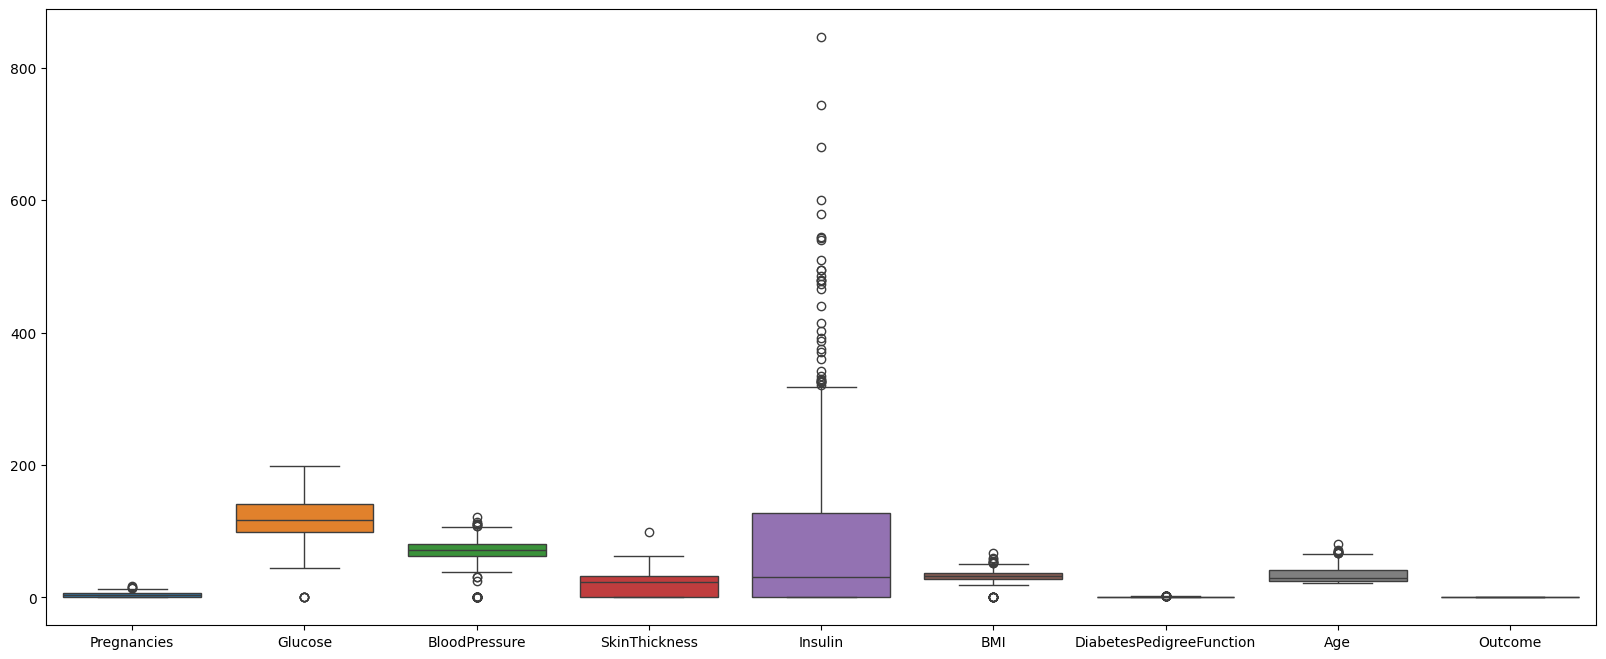

In [11]:
plt.figure(figsize = (20, 8))
sns.boxplot(data = df, width = 0.8)
plt.show()

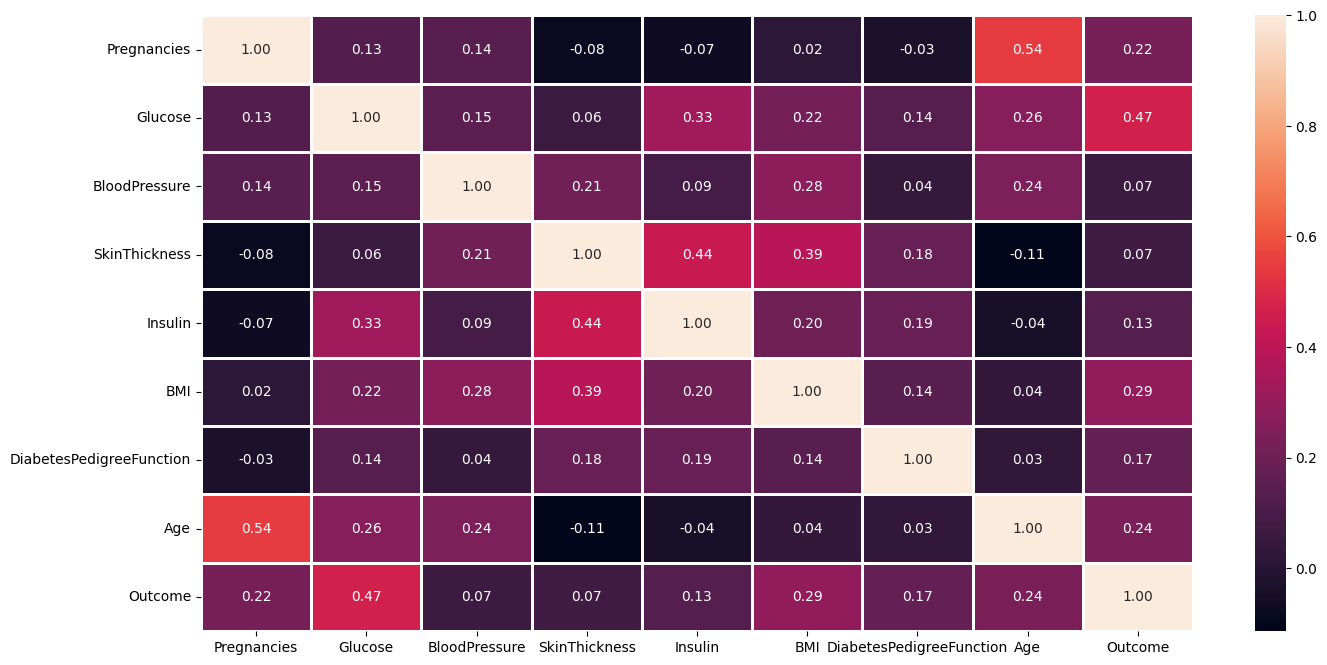

In [12]:
fig, ax = plt.subplots(figsize = (16, 8))
sns.heatmap(df.corr(), annot = True, fmt = '1.2f', annot_kws = {'size' : 10}, linewidth = 1)
plt.show()

# **Tiền xử lý dữ liệu**

### **Xử lý dữ liệu bằng 0**

In [13]:
cols_invalid_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Thay 0 bằng giá trị trung bình
for col in cols_invalid_zero:
    df[col] = df[col].replace(0, df[col].mean())

In [14]:
cols_invalid_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

zero_counts = df[cols_invalid_zero].apply(lambda x: (x == 0).sum())

print("Số giá trị 0 (không hợp lý) trong các cột:")
print(zero_counts)

Số giá trị 0 (không hợp lý) trong các cột:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


### Chuẩn hóa dữ liệu

In [15]:
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Cột cần scale
cols_to_scale = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI',
                 'DiabetesPedigreeFunction','Age']

scaler = RobustScaler()

# Scale trực tiếp lên X_train và X_test
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [16]:
X_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
60,2,-0.871795,-0.180908,-0.214902,0.000000,-0.000820,-0.184016,-0.5000
618,9,-0.153846,0.625000,0.087233,0.000000,-0.419890,2.443251,1.3125
346,1,0.538462,-1.625000,-0.348932,0.064074,-0.364641,0.756212,-0.4375
294,0,1.102564,-1.375000,-0.214902,0.000000,-1.116022,-0.318334,2.2500
231,6,0.410256,0.500000,1.221263,5.809760,1.569061,-0.361316,1.0625


# **Hồi quy không điều chuẩn**

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr = LogisticRegression(max_iter=1000, solver='liblinear')
lr.fit(X_train, y_train)

# Dự đoán
y_test_pred = lr.predict(X_test)

# Classification report
report = classification_report(y_test, y_test_pred, target_names=['No Diabetes', 'Diabetes'], output_dict=True)

# Chuyển thành DataFrame để in đẹp
report_df = pd.DataFrame(report).T
pd.set_option('display.float_format', lambda x: '%.2f' % x)
print(report_df)

              precision  recall  f1-score  support
No Diabetes        0.81    0.84      0.82    99.00
Diabetes           0.69    0.64      0.66    55.00
accuracy           0.77    0.77      0.77     0.77
macro avg          0.75    0.74      0.74   154.00
weighted avg       0.76    0.77      0.76   154.00


In [18]:
coef = pd.Series(lr.coef_[0], index=X_train.columns)

print("Hệ số β (Logistic Regression):")
print(coef)

# Biến có hệ số lớn nhất theo trị tuyệt đối
top_var = coef.abs().idxmax()
print(f"\nBiến ảnh hưởng mạnh nhất tới Outcome: {top_var} với hệ số β = {coef[top_var]:.3f}")

Hệ số β (Logistic Regression):
Pregnancies                 0.06
Glucose                     1.44
BloodPressure              -0.21
SkinThickness               0.02
Insulin                    -0.10
BMI                         0.94
DiabetesPedigreeFunction    0.23
Age                         0.54
dtype: float64

Biến ảnh hưởng mạnh nhất tới Outcome: Glucose với hệ số β = 1.439


# **Lasso**

### Alpha theo LassoCV

In [19]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import classification_report

# Logistic Regression với L1, tự chọn C tốt nhất qua CV
lr_cv = LogisticRegressionCV(
    Cs=10,              # thử 10 mức C khác nhau
    cv=10,              # 10-fold cross-validation
    penalty='l1',
    solver='liblinear',
    max_iter=1000,
    scoring='f1',
    refit=True
)
lr_cv.fit(X_train, y_train)

best_C = lr_cv.C_[0]
print(f"C tốt nhất (tự động): {best_C:.4f}")

# Dự đoán test
y_test_pred = lr_cv.predict(X_test)

# In classification report
report = classification_report(y_test, y_test_pred, target_names=['No Diabetes', 'Diabetes'])
print(report)

C tốt nhất (tự động): 0.3594
              precision    recall  f1-score   support

 No Diabetes       0.81      0.85      0.83        99
    Diabetes       0.70      0.64      0.67        55

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.75       154
weighted avg       0.77      0.77      0.77       154



In [27]:
feature_names = X_train.columns

# Lấy hệ số beta cho class 1
beta_lasso = pd.Series(lr_cv.coef_[0], index=feature_names)

print("Hệ số β của các biến (class Diabetes):")
print(beta_lasso)


Hệ số β của các biến (class Diabetes):
Pregnancies                 0.06
Glucose                     1.38
BloodPressure              -0.11
SkinThickness               0.00
Insulin                    -0.08
BMI                         0.86
DiabetesPedigreeFunction    0.19
Age                         0.46
dtype: float64


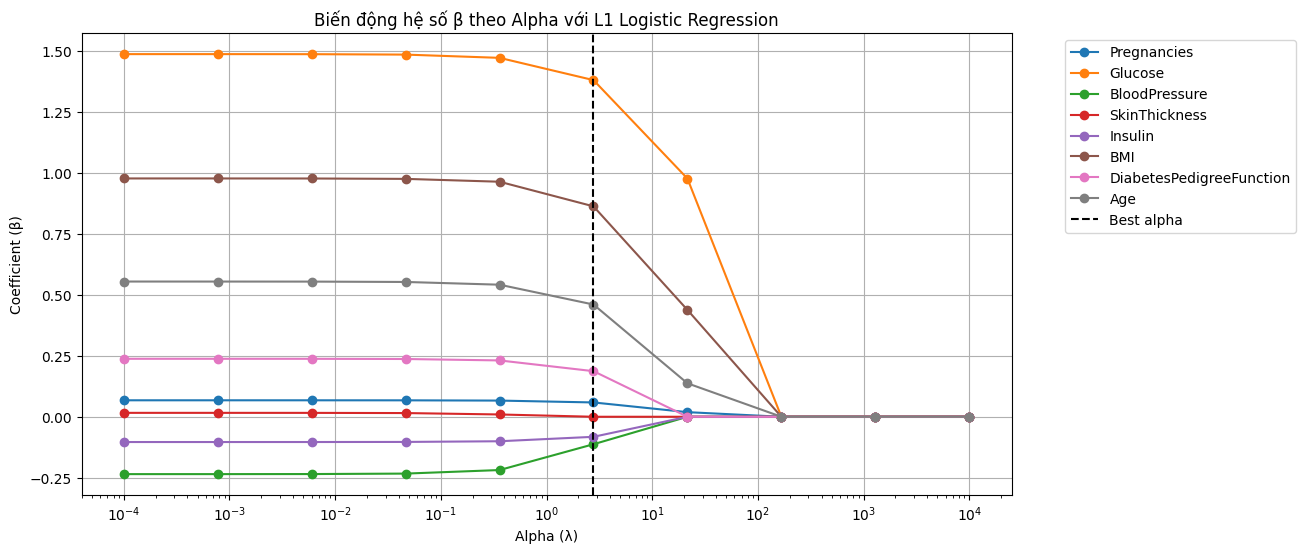

In [30]:
alphas = np.logspace(-4, 4, 10)  # alpha = 1/C
feature_names = X_train.columns

coef_list = []

for alpha in alphas:
    C = 1 / alpha
    lr = LogisticRegression(penalty='l1', solver='liblinear', C=C, max_iter=1000)
    lr.fit(X_train, y_train)
    coef_list.append(lr.coef_[0])

coef_df = pd.DataFrame(coef_list, index=alphas, columns=feature_names)

# Giả sử best_alpha là alpha tương ứng C tốt nhất
best_C = lr_cv.C_[0]       # từ LogisticRegressionCV
best_alpha = 1 / best_C

# Vẽ Lasso path
plt.figure(figsize=(12,6))
for col in feature_names:
    plt.plot(coef_df.index, coef_df[col], marker='o', label=col)

# Vẽ đường đứng tại alpha tốt nhất
plt.axvline(x=best_alpha, color='black', linestyle='--', label='Best alpha')

plt.xscale('log')
plt.xlabel('Alpha (λ)')
plt.ylabel('Coefficient (β)')
plt.title('Biến động hệ số β theo Alpha với L1 Logistic Regression')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

# **Ridge**

In [36]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import classification_report

# Logistic Regression với L2 (Ridge), tự chọn C tốt nhất qua CV
lr_ridge_cv = LogisticRegressionCV(
    Cs=10,
    cv=10,              # 10-fold cross-validation
    penalty='l2',       # L2 = Ridge
    solver='liblinear', # liblinear hỗ trợ L2
    max_iter=1000,
    scoring='f1',
    refit=True
)
lr_ridge_cv.fit(X_train, y_train)

best_C_ridge = lr_ridge_cv.C_[0]
print(f"C tốt nhất Ridge (tự động): {best_C_ridge:.4f}")

# Dự đoán test
y_test_pred_ridge = lr_ridge_cv.predict(X_test)

# In classification report
report_ridge = classification_report(
    y_test,
    y_test_pred_ridge,
    target_names=['No Diabetes', 'Diabetes']
)
print(report_ridge)

C tốt nhất Ridge (tự động): 0.0464
              precision    recall  f1-score   support

 No Diabetes       0.81      0.85      0.83        99
    Diabetes       0.70      0.64      0.67        55

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.75       154
weighted avg       0.77      0.77      0.77       154



In [38]:
beta_ridge = pd.Series(lr_ridge_cv.coef_[0], index=X_train.columns)

print("Hệ số β của các biến (Ridge Logistic Regression, class Diabetes):")
print(beta_ridge)

Hệ số β của các biến (Ridge Logistic Regression, class Diabetes):
Pregnancies                 0.015
Glucose                     0.966
BloodPressure              -0.008
SkinThickness               0.028
Insulin                    -0.054
BMI                         0.588
DiabetesPedigreeFunction    0.147
Age                         0.387
dtype: float64


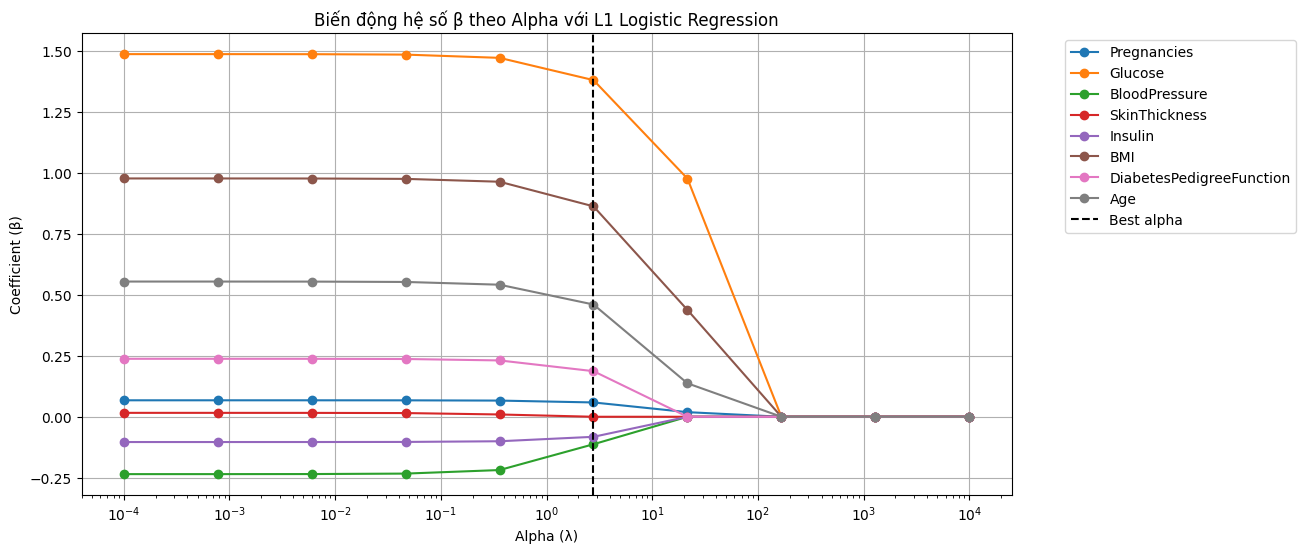

In [37]:
alphas = np.logspace(-4, 4, 10)  # alpha = 1/C
feature_names = X_train.columns

coef_list = []

for alpha in alphas:
    C = 1 / alpha
    lr = LogisticRegression(penalty='l1', solver='liblinear', C=C, max_iter=1000)
    lr.fit(X_train, y_train)
    coef_list.append(lr.coef_[0])

coef_df = pd.DataFrame(coef_list, index=alphas, columns=feature_names)

# Lấy alpha tốt nhất từ LogisticRegressionCV
best_C = lr_cv.C_[0]       # hoặc lr_ridge_cv.C_[0] nếu Ridge
best_alpha = 1 / best_C

# Vẽ path
plt.figure(figsize=(12,6))
for col in feature_names:
    plt.plot(coef_df.index, coef_df[col], marker='o', label=col)

# Vẽ đường vertical tại alpha tốt nhất
plt.axvline(x=best_alpha, color='black', linestyle='--', label='Best alpha')

plt.xscale('log')
plt.xlabel('Alpha (λ)')
plt.ylabel('Coefficient (β)')
plt.title('Biến động hệ số β theo Alpha với L1 Logistic Regression')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

# **So sánh chung OLS, Lasso và Ridge**

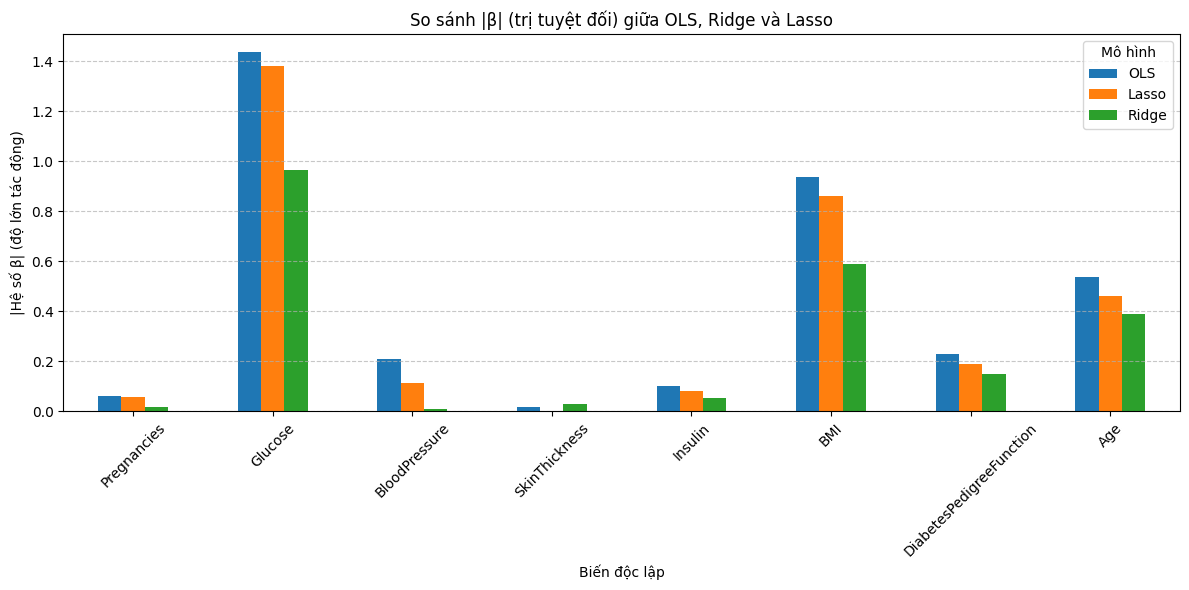

In [39]:
coef_df = pd.DataFrame({
    'OLS': coef,
    'Lasso': beta_lasso,
    'Ridge': beta_ridge
})

coef_df_abs = coef_df.abs()

# Vẽ biểu đồ cột theo trị tuyệt đối
coef_df_abs.plot(kind='bar', figsize=(12, 6))
plt.title("So sánh |β| (trị tuyệt đối) giữa OLS, Ridge và Lasso")
plt.xlabel("Biến độc lập")
plt.ylabel("|Hệ số β| (độ lớn tác động)")
plt.xticks(rotation=45)
plt.legend(title="Mô hình")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# **ElasticNet**

In [ ]:
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

model_cv = ElasticNetCV(
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1],
    alphas=None,
    cv=5,
    random_state=42
)
model_cv.fit(X_train, y_train)

# Kết quả tham số tối ưu
print("Tham số tối ưu:")
print(f"alpha: {model_cv.alpha_:.5f}")
print(f"l1_ratio: {model_cv.l1_ratio_:.3f}")

# Dự đoán
y_pred_train = model_cv.predict(X_train)
y_pred_test = model_cv.predict(X_test)

# Đánh giá
print("\nHiệu suất ElasticNetCV:")
print(f"R² train: {r2_score(y_train, y_pred_train):.3f}")
print(f"R² test:  {r2_score(y_test, y_pred_test):.3f}")
print(f"MSE train: {mean_squared_error(y_train, y_pred_train):.3f}")
print(f"MSE test:  {mean_squared_error(y_test, y_pred_test):.3f}")
print(f"MAE train: {mean_absolute_error(y_train, y_pred_train):.3f}")
print(f"MAE test:  {mean_absolute_error(y_test, y_pred_test):.3f}")

In [ ]:
# Hệ số β
coef = pd.Series(model_cv.coef_, index=X_train.columns)
print("\nHệ số β (ElasticNetCV):")
print(coef.sort_values(ascending=False))

# **Adaptive Lasso**

In [ ]:
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

ols = LinearRegression()
ols.fit(X_train, y_train)
beta_init = ols.coef_

# Bước: tính trọng số
epsilon = 1e-4  # để tránh chia cho 0
weights = 1 / (np.abs(beta_init) + epsilon)

# Bước: chuẩn hóa dữ liệu theo trọng số
X_train_weighted = X_train / weights
X_test_weighted = X_test / weights

# Bước: chạy LassoCV trên dữ liệu đã điều chỉnh
lasso_adaptive = LassoCV(cv=5, random_state=42)
lasso_adaptive.fit(X_train_weighted, y_train)

# Dự đoán
y_pred_train = lasso_adaptive.predict(X_train_weighted)
y_pred_test = lasso_adaptive.predict(X_test_weighted)

# Đánh giá
print("Hiệu suất Adaptive Lasso:")
print(f"R² train: {r2_score(y_train, y_pred_train):.3f}")
print(f"R² test:  {r2_score(y_test, y_pred_test):.3f}")
print(f"MSE train: {mean_squared_error(y_train, y_pred_train):.3f}")
print(f"MSE test:  {mean_squared_error(y_test, y_pred_test):.3f}")
print(f"MAE train: {mean_absolute_error(y_train, y_pred_train):.3f}")
print(f"MAE test:  {mean_absolute_error(y_test, y_pred_test):.3f}")

In [ ]:
# Hệ số β sau khi hiệu chỉnh lại
coef_adaptive = lasso_adaptive.coef_ / weights
coef_ada = pd.Series(coef_adaptive, index=X_train.columns)
print("\nHệ số β (Adaptive Lasso):")
print(coef_ada)

# **So sánh chung**

In [ ]:
df_compare = pd.DataFrame({
    'Lasso': beta_lasso.abs(),
    'Adaptive Lasso': coef_ada.abs()
})

# Vẽ biểu đồ cột so sánh
plt.figure(figsize=(12,6))
df_compare.plot(kind='bar', figsize=(12,6))
plt.title('So sánh |β| giữa Lasso và Adaptive Lasso', fontsize=14)
plt.xlabel('Tên biến', fontsize=12)
plt.ylabel('|Hệ số β| (độ lớn tuyệt đối)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()